<a href="https://colab.research.google.com/github/skyish21/AIML-Python/blob/main/DL/DL_6_Chest_X_Rays_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pneumonia vs Normal Chest X-rays
**Task**: Classify chest X-ray images as either "Pneumonia" or "Normal"

### Installing Libraries

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
"""
Go to: https://www.kaggle.com/account

Scroll to API → Click "Create New API Token"

It will download kaggle.json
"""

'\nGo to: https://www.kaggle.com/account\n\nScroll to API → Click "Create New API Token"\n\nIt will download kaggle.json\n'

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### Dataset collection

In [7]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 98% 2.26G/2.29G [00:29<00:00, 82.2MB/s]
100% 2.29G/2.29G [00:29<00:00, 83.0MB/s]


In [9]:
# Extracting the compressed file
from zipfile import ZipFile

# Open the zip file
data = ZipFile('/content/chest-xray-pneumonia.zip')

# Use the opened zip file object to extract all contents
with data as zip:
  zip.extractall()
  print('Done')

Done


### Dataset Evaluation

In [21]:
# count the number of  Pneumonia images in train set

import os

path, dirs, files = next(os.walk('/content/chest_xray/train/PNEUMONIA'))
file_count = len(files)
print(file_count)

3875


In [22]:
# count the number of Normal images in train set

import os

path, dirs, files = next(os.walk('/content/chest_xray/train/NORMAL'))
file_count = len(files)
print(file_count)

1341


In [77]:
import os

test_path = '/content/chest_xray/train'
normal_count = len(os.listdir(os.path.join(test_path, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(test_path, 'PNEUMONIA')))
total = normal_count + pneumonia_count

print(f"NORMAL: {normal_count}")
print(f"PNEUMONIA: {pneumonia_count}")
print(f"Total train images: {total}")

NORMAL: 1341
PNEUMONIA: 3875
Total train images: 5216


In [ ]:
# Total Train images: 5216
# There is a dataset imbalance

**Normal Chest X-ray**

- Clear lungs with visible rib outlines and airway structures

- Lungs appear dark (radiolucent) because they’re filled with air

- No white patches, opacities, or fluid

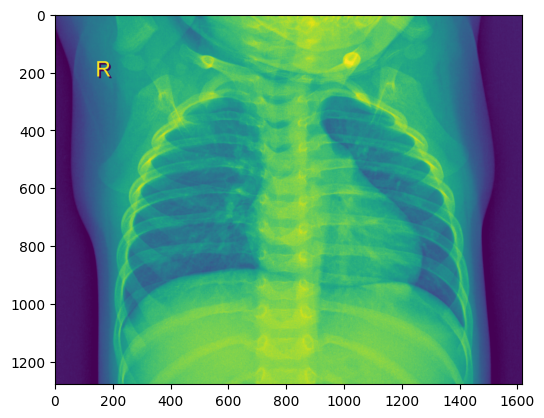

In [35]:
# Display Image of normal x-ray

import matplotlib.image as mpimg

img = mpimg.imread('/content/chest_xray/train/NORMAL/IM-0122-0001.jpeg')
img_plot = plt.imshow(img)
plt.show()

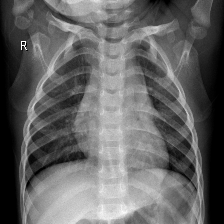

In [32]:
# Alternative way
# Display Image of normal x-ray

import cv2

img = cv2.imread('/content/chest_xray/train/NORMAL/IM-0117-0001.jpeg')

# Resize to 224x224 (cv2 shows enlarged image if not resized)
resized = cv2.resize(img, (224, 224))
cv2_imshow(resized)

**Pneumonia Chest X-ray**

- Shows white cloudy patches (called consolidation or infiltrates) where air is replaced by pus/fluid

- Often localized to one lung or one region

- Caused by infection (bacterial/viral)

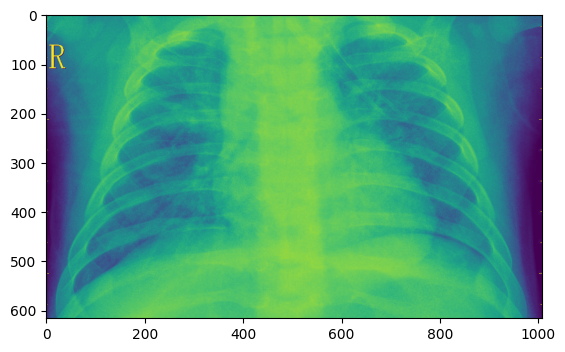

In [37]:
# Display Image of pneumonia x-ray (virus)

import matplotlib.image as mpimg

img = mpimg.imread('/content/chest_xray/train/PNEUMONIA/person1003_virus_1685.jpeg')
img_plot = plt.imshow(img)
plt.show()

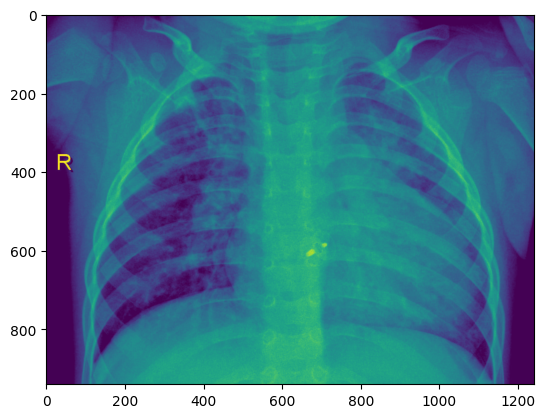

In [38]:
# Display Image of pneumonia x-ray (bacterial)

import matplotlib.image as mpimg

img = mpimg.imread('/content/chest_xray/train/PNEUMONIA/person1002_bacteria_2933.jpeg')
img_plot = plt.imshow(img)
plt.show()

In [39]:
# All the images are of different size. Model needs to be trained on images of similar size.
# Model can be trained on Gray scale images if RGB features aren't necesarry.
# Training Model on Gray scale images requires lesser time.

### Pre-Processing the Images

In [41]:
import cv2
from PIL import Image

Training set

In [42]:
# Creating a directory for resized images
os.mkdir('/content/train_resize')

In [47]:
# Creating a directory for resized images
os.mkdir('/content/train_resize/NORMAL')

In [44]:
# Creating a directory for resized images
os.mkdir('/content/train_resize/PNEUMONIA')

In [48]:
train_set_normal = "/content/chest_xray/train/NORMAL"

file_list = os.listdir(train_set_normal)

for i in range(len(file_list)):

  filename = file_list[i]
  img_path = '/content/chest_xray/train/NORMAL/' + filename

  # Using PIL library
  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  new_img_path = '/content/train_resize/NORMAL/' + filename
  img.save(new_img_path)

In [89]:
train_set_pneumonia = "/content/chest_xray/train/PNEUMONIA"

file_list = os.listdir(train_set_pneumonia)

for i in range(1341):

  filename = file_list[i]
  img_path = '/content/chest_xray/train/PNEUMONIA/' + filename

  # Using PIL library
  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  new_img_path = '/content/train_resize/PNEUMONIA/' + filename
  img.save(new_img_path)

In [ ]:
# range = 1341 to balance the dataset with normal x-rays

Testing set

In [76]:
import os

test_path = '/content/chest_xray/test'
normal_count = len(os.listdir(os.path.join(test_path, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(test_path, 'PNEUMONIA')))
total = normal_count + pneumonia_count

print(f"NORMAL: {normal_count}")
print(f"PNEUMONIA: {pneumonia_count}")
print(f"Total test images: {total}")


NORMAL: 234
PNEUMONIA: 390
Total test images: 624


In [78]:
# Creating a directory for resized images
os.mkdir('/content/test_resize')

In [79]:
# Creating a directory for resized images
os.mkdir('/content/test_resize/NORMAL')

In [80]:
# Creating a directory for resized images
os.mkdir('/content/test_resize/PNEUMONIA')

In [82]:
test_set_normal = "/content/chest_xray/test/NORMAL"

file_list = os.listdir(test_set_normal)

for i in range(len(file_list)):

  filename = file_list[i]
  img_path = '/content/chest_xray/test/NORMAL/' + filename

  # Using PIL library
  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  new_img_path = '/content/test_resize/NORMAL/' + filename
  img.save(new_img_path)

In [84]:
test_set_pneumonia = "/content/chest_xray/test/PNEUMONIA"

file_list = os.listdir(test_set_pneumonia)

for i in range(len(file_list)):

  filename = file_list[i]
  img_path = '/content/chest_xray/test/PNEUMONIA/' + filename

  # Using PIL library
  img = Image.open(img_path)
  img = img.resize((224,224))
  img = img.convert('RGB')

  new_img_path = '/content/test_resize/PNEUMONIA/' + filename
  img.save(new_img_path)

### Visualisation of dataset

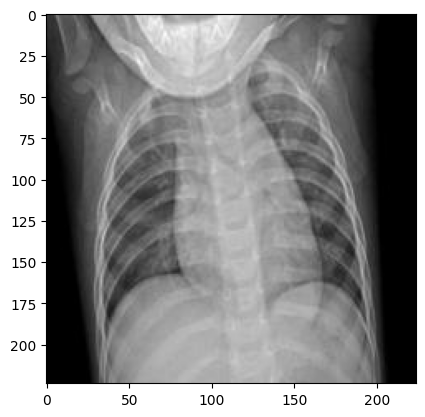

In [72]:
# Display resized normal x-ray image
img = mpimg.imread('/content/train_resize/NORMAL/IM-0133-0001.jpeg')
img_plot = plt.imshow(img, cmap="gray")
plt.show()

In [73]:
img.shape

(224, 224, 3)

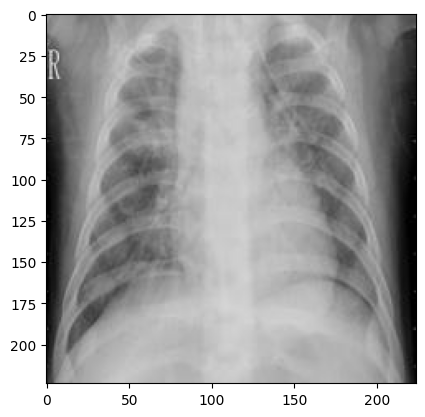

In [74]:
# Display resized pneumonia x-ray image
img = mpimg.imread('/content/train_resize/PNEUMONIA/person1003_virus_1685.jpeg')
img_plot = plt.imshow(img)
plt.show()

In [75]:
img.shape

(224, 224, 3)

### Labels

In [107]:
# Generate labels for training set

train_resize = '/content/train_resize'
labels_train = []

for folder in ['NORMAL', 'PNEUMONIA']:
  folder_path = os.path.join(train_resize, folder)
  num_files = len(os.listdir(folder_path))

  if folder == 'NORMAL':
    labels_train.extend([0] * num_files)
  else:
    labels_train.extend([1] * num_files)

In [108]:
print(labels_train[:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [109]:
print(labels_train[1341:1351]) # first 1341 normal and last 1341 pneumonia

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [111]:
# Generate labels for testing set

test_resize = '/content/test_resize'
labels_test = []

for folder in ['NORMAL', 'PNEUMONIA']:
  folder_path = os.path.join(test_resize, folder)
  num_files = len(os.listdir(folder_path))

  if folder == 'NORMAL':
    labels_test.extend([0] * num_files)
  else:
    labels_test.extend([1] * num_files)

In [96]:
# Count the train_resize images

train_resize = '/content/train_resize'

normal_count = len(os.listdir(os.path.join(train_resize, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_resize, 'PNEUMONIA')))
total = normal_count + pneumonia_count

print(f"NORMAL: {normal_count}")
print(f"PNEUMONIA: {pneumonia_count}")
print(f"Total train images: {total}")

NORMAL: 1341
PNEUMONIA: 1341
Total train images: 2682


In [97]:
# Count no. of unique labels

np.unique(labels_train, return_counts=True)

(array([0, 1]), array([1341, 1341]))

### Convert to Numpy Array

In [101]:
xtrain = []

train_resize = "/content/train_resize"

for folder in ["NORMAL", "PNEUMONIA"]:
    folder_path = os.path.join(train_resize, folder)

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)

        # Open
        img = Image.open(img_path)
        img_array = np.array(img).astype('float32')
        xtrain.append(img_array)

# Convert to NumPy array
xtrain = np.array(xtrain)
print(xtrain.shape)

(2682, 224, 224, 3)


In [105]:
type(xtrain)

numpy.ndarray

In [102]:
xtest = []

test_resize = "/content/test_resize"

for folder in ["NORMAL", "PNEUMONIA"]:
    folder_path = os.path.join(test_resize, folder)

    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)

        # Open
        img = Image.open(img_path)
        img_array = np.array(img).astype('float32')
        xtest.append(img_array)

# Convert to NumPy array
xtest = np.array(xtest)
print(xtest.shape)

(624, 224, 224, 3)


In [106]:
type(xtest)

numpy.ndarray

In [112]:
# Convert labels to numpy array
ytrain = np.array(labels_train)
ytest = np.array(labels_test)

### Scaling the Dataset

In [104]:
xtrain_scaled = xtrain/255
xtest_scaled = xtest/255

### Build NN Model

In [113]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [114]:
DN_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [115]:
DN_model.trainable = False

In [116]:
model = tf.keras.Sequential([

    DN_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(2, activation='softmax') # categorical classification
])

In [117]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [119]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [151]:
model.fit(xtrain_scaled, ytrain, epochs=5)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 427s 5s/step - accuracy: 0.5695 - loss: 1.2796
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 453s 5s/step - accuracy: 0.8377 - loss: 0.3634
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 445s 5s/step - accuracy: 0.8741 - loss: 0.2929
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 438s 5s/step - accuracy: 0.8939 - loss: 0.2686
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 447s 5s/step - accuracy: 0.8992 - loss: 0.2573


In [152]:
loss, acc = model.evaluate(xtest_scaled, ytest)
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.8109 - loss: 0.4064
Loss: 0.31010428071022034
Accuracy: 0.8669871687889099


### Build a Predictive system

In [153]:
def model_predict():

  img_path = input("Enter the path of the image: ")

  img = cv2.imread(img_path)

  # Resize the image
  img_resize = cv2.resize(img, (224, 224))
  cv2_imshow(img_resize)

  # If grayscale, convert to RGB
  if len(img_resize.shape) == 2:  # Grayscale: (H, W)
    img_rgb = cv2.cvtColor(img_resize, cv2.COLOR_GRAY2RGB)
  else:
    img_rgb = cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB)

  # Convert to numpy array
  img_array = np.array(img_rgb).astype('float32')

  # Scale the image
  img_scaled = img_array/255

  # Reshape (lets model know the no. of images inputed)
  img_reshape = np.reshape(img_scaled, [1,224,224,3])

  # Predict the image
  prediction = model.predict(img_reshape)
  print(prediction)

  # Get highest probabilty
  pred_label = np.argmax(prediction)

  if pred_label == 0:
    print("The X-Ray is Normal.")
  else:
    print("The X-Ray shows Pneumonia.")

Enter the path of the image: /content/normal img.jpg


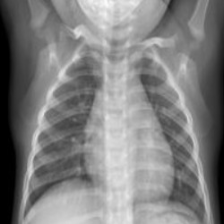

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
[[0.8873825  0.11261752]]
The X-Ray is Normal.


In [154]:
model_predict()

Enter the path of the image: /content/pneumonia img.jpg


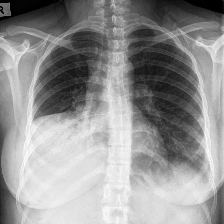

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
The X-Ray shows Pneumonia.


In [131]:
model_predict()